Simulation de 10 corps en cours sur 94900 jours...


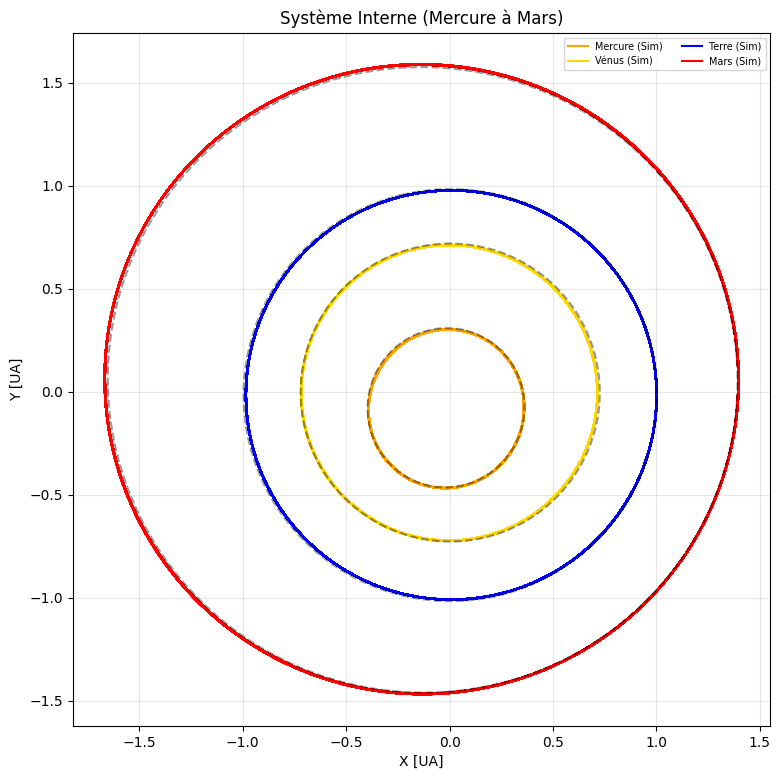

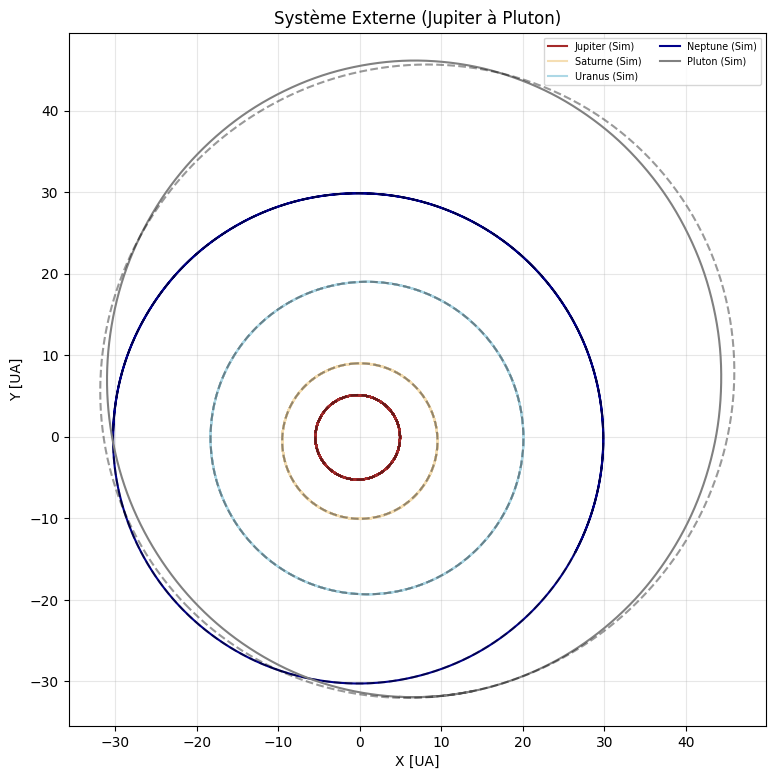

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Internal_constants import *
from Internal_functions import *


# --- CONFIGURATION ET DONNÉES ---
G_sim = G_norm  

# Regroupement des données initiales (Soleil + 9 planètes)
# Note : Assure-toi que ces variables sont bien définies dans Internal_constants
pos_init = np.array([
    [X0_Soleil_norm, Y0_Soleil_norm, Z0_Soleil_norm],
    [X0_Mercure_norm, Y0_Mercure_norm, Z0_Mercure_norm],
    [X0_Venus_norm, Y0_Venus_norm, Z0_Venus_norm],
    [X0_Terre_norm, Y0_Terre_norm, Z0_Terre_norm],
    [X0_Mars_norm, Y0_Mars_norm, Z0_Mars_norm],
    [X0_Jupiter_norm, Y0_Jupiter_norm, Z0_Jupiter_norm],
    [X0_Saturne_norm, Y0_Saturne_norm, Z0_Saturne_norm],
    [X0_Uranus_norm, Y0_Uranus_norm, Z0_Uranus_norm],
    [X0_Neptune_norm, Y0_Neptune_norm, Z0_Neptune_norm],
    [X0_Pluton_norm, Y0_Pluton_norm, Z0_Pluton_norm]
])

vel_init = np.array([
    [VX0_Soleil_norm, VY0_Soleil_norm, VZ0_Soleil_norm],
    [VX0_Mercure_norm, VY0_Mercure_norm, VZ0_Mercure_norm],
    [VX0_Venus_norm, VY0_Venus_norm, VZ0_Venus_norm],
    [VX0_Terre_norm, VY0_Terre_norm, VZ0_Terre_norm],
    [VX0_Mars_norm, VY0_Mars_norm, VZ0_Mars_norm],
    [VX0_Jupiter_norm, VY0_Jupiter_norm, VZ0_Jupiter_norm],
    [VX0_Saturne_norm, VY0_Saturne_norm, VZ0_Saturne_norm],
    [VX0_Uranus_norm, VY0_Uranus_norm, VZ0_Uranus_norm],
    [VX0_Neptune_norm, VY0_Neptune_norm, VZ0_Neptune_norm],
    [VX0_Pluton_norm, VY0_Pluton_norm, VZ0_Pluton_norm]
])

masses = np.array([
    M_Soleil_norm, M_Mercure_norm, M_Venus_norm, M_Terre_norm, M_Mars_norm,
    M_Jupiter_norm, M_Saturne_norm, M_Uranus_norm, M_Neptune_norm, M_Pluton_norm
])

names = ["Soleil", "Mercure", "Vénus", "Terre", "Mars", "Jupiter", "Saturne", "Uranus", "Neptune", "Pluton"]
colors = ['yellow', 'orange', 'gold', 'blue', 'red', 'brown', 'wheat', 'lightblue', 'darkblue', 'gray']


# --- PRÉPARATION DES DONNÉES ---
nBody = len(masses)
# On concatène toutes les positions, puis toutes les vitesses en un seul vecteur plat
curr_state = np.concatenate([pos_init.flatten(), vel_init.flatten()])
 
# --- EXECUTION ---
tf = 365 * 260
h = 0.5
steps = int(tf/h)
trajs = np.zeros((steps, nBody, 3))

print(f"Simulation de {nBody} corps en cours sur {tf} jours...")

for i in range(steps):
    # On stocke uniquement les positions pour l'affichage
    trajs[i] = curr_state[:3*nBody].reshape((nBody, 3))
    # Calcul du pas suivant
    curr_state = rk4_step_nBody(curr_state, masses, nBody, h)


# --- VISUALISATION ---

def plot_2d(indices, title):
    plt.figure(figsize=(9,9))
    theta = np.linspace(0, 2*np.pi, 500)
    
    for idx in indices:
        name = names[idx]
        # Trajectoire RK4 relative au Soleil (trajs[:, 0])
        x_sim = trajs[:, idx, 0] - trajs[:, 0, 0]
        y_sim = trajs[:, idx, 1] - trajs[:, 0, 1]
        plt.plot(x_sim, y_sim, color=colors[idx], label=f"{name} (Sim)", linewidth=1.5)
        
        # Superposition Képlerienne théorique
        if name in KEPLER_ELEMENTS:
            a, e, omega_deg = KEPLER_ELEMENTS[name]
            omega = np.radians(omega_deg)
            r_theo = (a * (1 - e**2)) / (1 + e * np.cos(theta))
            x_theo = r_theo * np.cos(theta + omega)
            y_theo = r_theo * np.sin(theta + omega)
            plt.plot(x_theo, y_theo, 'k--', alpha=0.4)

    plt.axis('equal')
    plt.title(title)
    plt.xlabel("X [UA]")
    plt.ylabel("Y [UA]")
    plt.legend(loc='upper right', fontsize='x-small', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

# Affichage des résultats
plot_2d([1, 2, 3, 4], "Système Interne (Mercure à Mars)")
plot_2d([5, 6, 7, 8, 9], "Système Externe (Jupiter à Pluton)")

Simulation en cours pour analyse des forces...


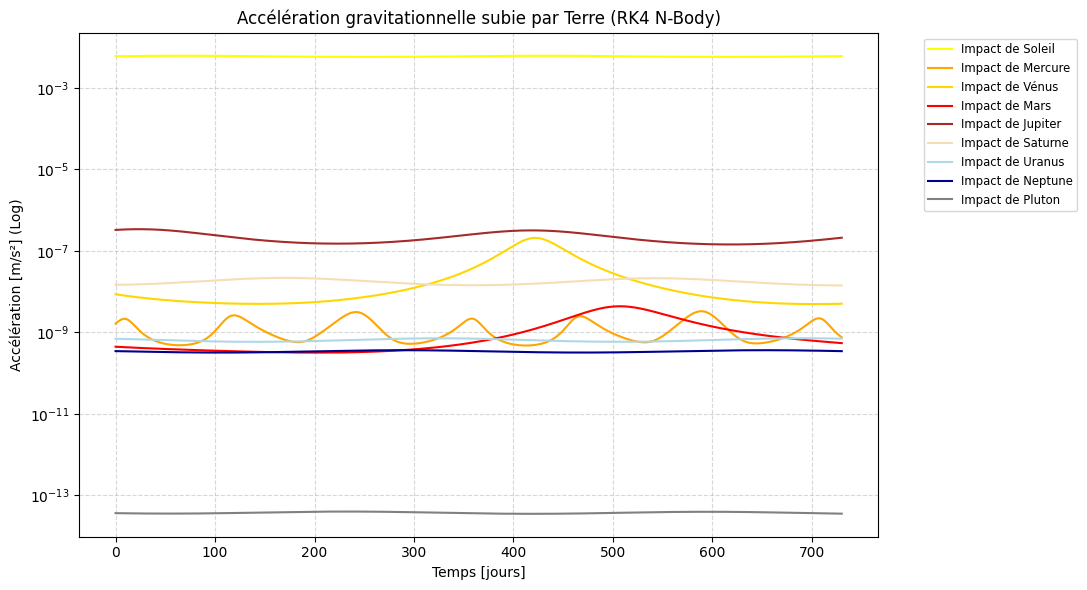


--- Accélération moyenne subie par Terre (m/s²) ---
Source       | Accélération Moyenne
-----------------------------------
Soleil       | 6.01e-03 m/s²
Jupiter      | 2.15e-07 m/s²
Vénus        | 2.71e-08 m/s²
Saturne      | 1.77e-08 m/s²
Mercure      | 1.21e-09 m/s²
Mars         | 1.08e-09 m/s²
Uranus       | 6.47e-10 m/s²
Neptune      | 3.41e-10 m/s²
Pluton       | 3.71e-14 m/s²
-----------------------------------


In [ ]:
# --- CONFIGURATION DE L'ANALYSE ---
tf = 365 * 2 
h = 0.05
steps = int(tf/h)
nBody = len(masses)

# Initialisation de l'état complet (Positions + Vitesses)
curr_state = np.concatenate([pos_init.flatten(), vel_init.flatten()])
trajs = np.zeros((steps, nBody, 3))

print("Simulation en cours pour analyse des forces...")
for i in range(steps):
    # On extrait les positions pour le stockage et l'analyse future
    trajs[i] = curr_state[:3*nBody].reshape((nBody, 3))
    
    # Pas RK4 avec l'état complet
    curr_state = rk4_step_nBody(curr_state, masses, nBody, h)

# --- ANALYSE DES ACCÉLÉRATIONS SUR UNE PLANÈTE CIBLE ---
def analyser_impact(target_idx, trajectories, m):
    n_steps = len(trajectories)
    n_bodies = len(m)
    impacts = np.zeros((n_steps, n_bodies))
    
    # Conversion G_sim (UA^3/msol/j^2) vers m/s² :
    # On multiplie par (AU_en_m / Day_en_s^2)
    conv_factor = AU / (Day**2)
    
    for t in range(n_steps):
        p = trajectories[t] # p est (nBody, 3)
        for j in range(n_bodies):
            if j != target_idx:
                r_vec = p[j] - p[target_idx]
                dist = np.linalg.norm(r_vec)

                # Magnitude de l'accélération : G * Mj / dist^2
                # On utilise G_norm (la constante de ton fichier Internal_constants)
                acc_mag = (G_norm * m[j] / dist**2) * conv_factor
                impacts[t, j] = acc_mag
    return impacts

target = 3 # Index de la Terre
impacts_target = analyser_impact(target, trajs, masses)

# --- PLOT DES ACCÉLÉRATIONS ---
plt.figure(figsize=(11, 6))
time_axis = np.linspace(0, tf, steps)

for j in range(nBody):
    if j != target:
        plt.plot(time_axis, impacts_target[:, j], color=colors[j], label=f"Impact de {names[j]}", lw=1.5)

plt.yscale('log') 
plt.title(f"Accélération gravitationnelle subie par {names[target]} (RK4 N-Body)")
plt.xlabel("Temps [jours]")
plt.ylabel("Accélération [m/s²] (Log)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

# --- CALCUL ET AFFICHAGE DES MOYENNES ---
print(f"\n--- Accélération moyenne subie par {names[target]} (m/s²) ---")
print(f"{'Source':<12} | {'Accélération Moyenne':<20}")
print("-" * 35)

moyennes = np.mean(impacts_target, axis=0) 
indices_tries = np.argsort(moyennes)[::-1]

for idx in indices_tries:
    if idx != target:
        print(f"{names[idx]:<12} | {moyennes[idx]:.2e} m/s²")
print("-" * 35)